In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,
    Dropout, RandomFlip, RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

C:\Users\mirza\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [3]:
train_images, test_images = train_images/255.0 , test_images/255.0

In [4]:
train_images.shape

(50000, 32, 32, 3)

In [5]:
test_images.shape

(10000, 32, 32, 3)

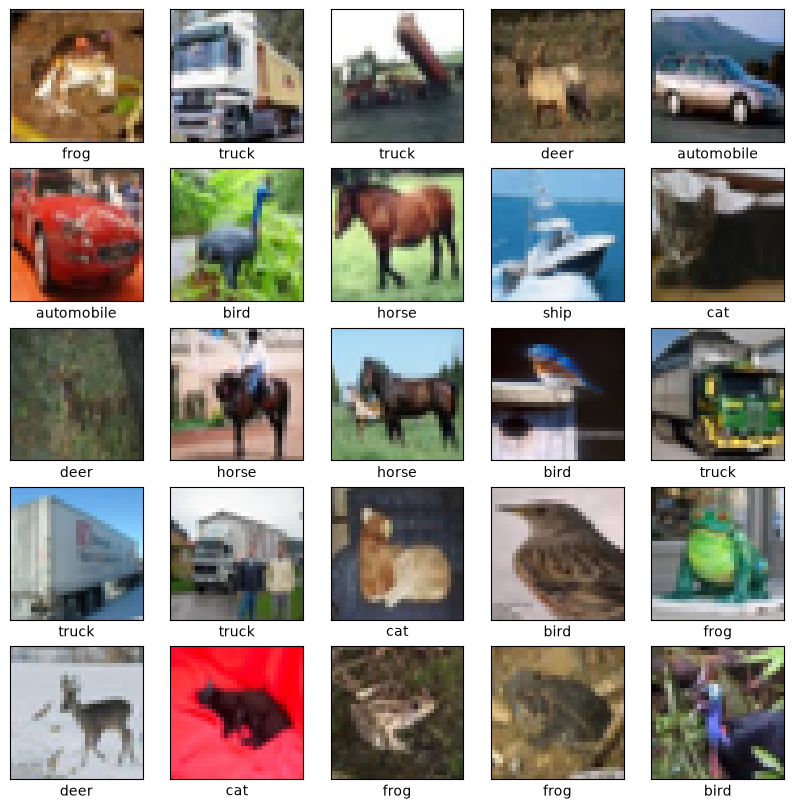

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

## Model

Using `leaky_relu` (your `CNN-Copy1` version, which scored a bit higher: 81.3% vs 80.0%). Swap it back to `elu` if you want to isolate that variable again — everything else below is independent of that choice.

In [7]:
L2_REG = 1e-4

model = models.Sequential([
    Input(shape=(32, 32, 3)),

    # Data augmentation — only active during model.fit(); Keras automatically
    # turns these off for evaluate()/predict(), so no separate "inference model" needed.
    RandomFlip("horizontal"),   # vertical flip would be wrong here — an upside-down truck isn't a natural CIFAR image
    RandomRotation(0.05),       # ~±18 degrees
    RandomZoom(0.1),
    RandomContrast(0.1),

    Conv2D(32, kernel_size=(3, 3), padding='same', activation='leaky_relu',
           kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    BatchNormalization(),
    Dropout(0.2),

    Conv2D(64, kernel_size=(3, 3), padding='same', activation='leaky_relu',
           kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    BatchNormalization(),
    Dropout(0.2),

    Conv2D(128, kernel_size=(3, 3), padding='same', activation='leaky_relu',
           kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(64, activation='leaky_relu', kernel_initializer='he_normal', kernel_regularizer=l2(L2_REG)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10),  # logits, no activation — paired with from_logits=True below
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8, 8, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 104,202 (407.04 KB)

 Trainable params: 103,178 (403.04 KB)

 Non-trainable params: 1,024 (4.00 KB)

## Train

`batch_size=64` (was 10) and the callbacks list is now a plain list (was accidentally a 1-tuple). `epochs=1000` is intentional — training relies on `EarlyStopping` to halt once `val_loss` stops improving, same as your original.

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=1,
    mode="min",
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

callbacks_list = [early_stopping, reduce_lr, checkpoint]  # no trailing comma this time

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_images, train_labels, batch_size=64,
    epochs=1000,
    callbacks=callbacks_list,
    validation_data=(test_images, test_labels)
)

Epoch 1/1000
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3796 - loss: 1.7777
Epoch 1: val_loss improved from None to 1.74282, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.3796 - loss: 1.7775 - val_accuracy: 0.4145 - val_loss: 1.7428 - learning_rate: 0.0010
Epoch 2/1000
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4963 - loss: 1.4525
Epoch 2: val_loss improved from 1.74282 to 1.42724, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.4963 - loss: 1.4525 - val_accuracy: 0.5275 - val_loss: 1.4272 - learning_rate: 0.0010
Epoch 3/1000
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5441 - loss: 1.3255
Epoch 3: val_loss did not improve from 1.42724
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.5441 - loss: 1.3255 - val_accuracy: 0.4380 - val_loss: 1.9240 - learning

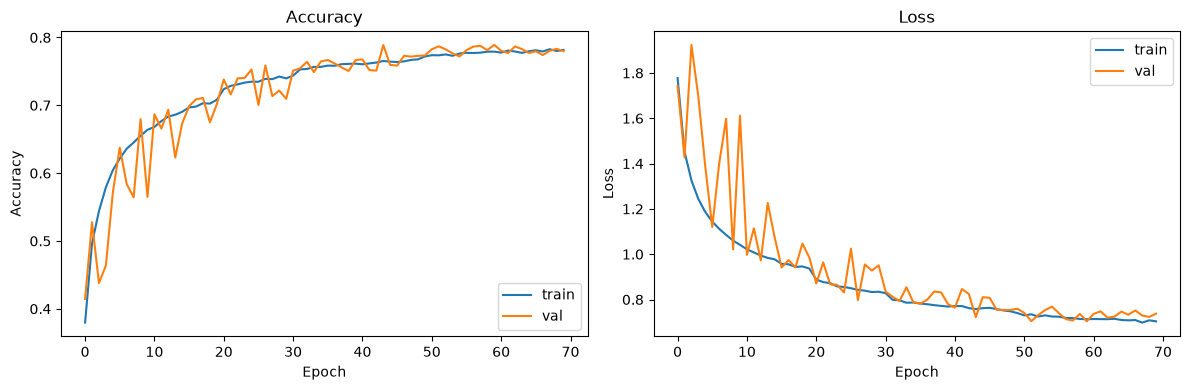

313/313 - 3s - 8ms/step - accuracy: 0.7891 - loss: 0.7041


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

In [11]:
test_acc

0.7890999913215637

In [12]:
logits = model.predict(test_images, batch_size=256, verbose=0)
probs = tf.nn.softmax(logits).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = test_labels.reshape(-1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

              precision    recall  f1-score   support

    airplane      0.813     0.834     0.823      1000
  automobile      0.910     0.914     0.912      1000
        bird      0.789     0.671     0.725      1000
         cat      0.715     0.508     0.594      1000
        deer      0.741     0.760     0.750      1000
         dog      0.816     0.593     0.687      1000
        frog      0.635     0.948     0.760      1000
       horse      0.815     0.849     0.832      1000
        ship      0.835     0.933     0.881      1000
       truck      0.877     0.881     0.879      1000

    accuracy                          0.789     10000
   macro avg      0.795     0.789     0.784     10000
weighted avg      0.795     0.789     0.784     10000



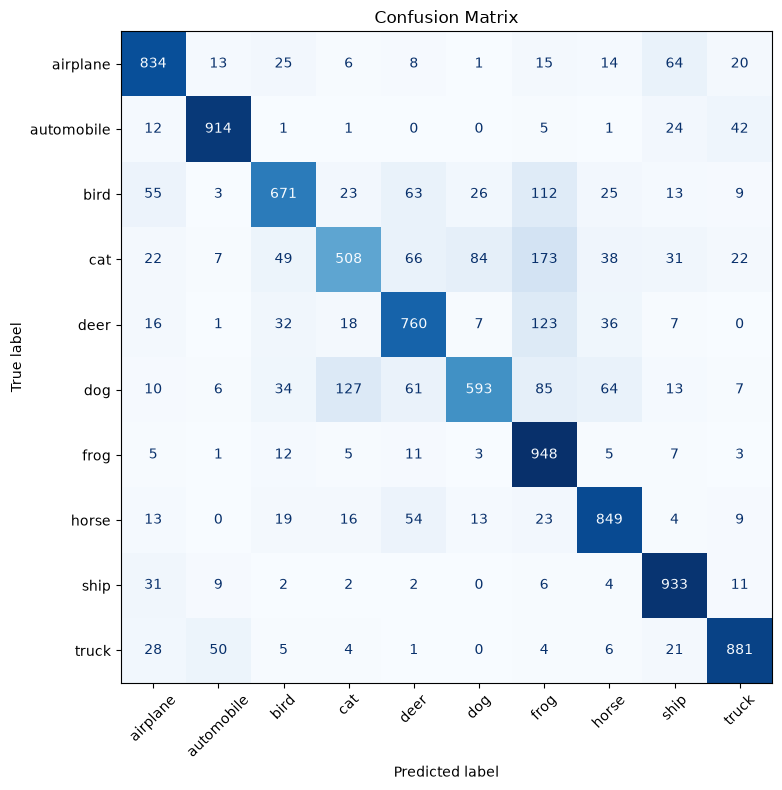

In [13]:
cm = confusion_matrix(y_true, y_pred, labels=range(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [14]:
# Macro ROC-AUC (one-vs-rest) and top-3 accuracy — two more angles beyond plain accuracy
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=10)
auc_macro = roc_auc_score(y_true_onehot, probs, average='macro', multi_class='ovr')
print(f"Macro ROC-AUC (one-vs-rest): {auc_macro:.4f}")

top3_acc = tf.keras.metrics.sparse_top_k_categorical_accuracy(y_true, probs, k=3)
print(f"Top-3 accuracy: {np.mean(top3_acc):.4f}")

Macro ROC-AUC (one-vs-rest): 0.9779
Top-3 accuracy: 0.9528


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Prediction: dog


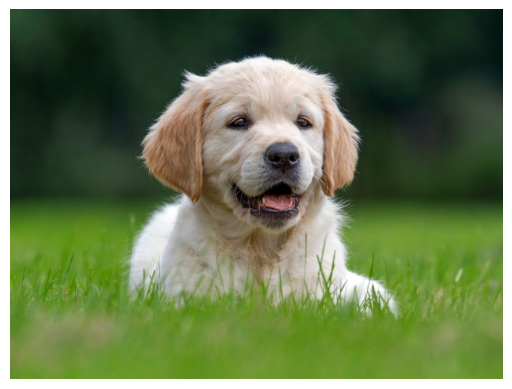

In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

img_path = 'datasets/dog.jpg'

# 1. Load the original, full-resolution image just for displaying
img_for_display = image.load_img(img_path)

# 2. Load and shrink the image to 32x32 specifically for the model
img_for_model = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img_for_model)
img_array = img_array / 255.0
img_input = np.expand_dims(img_array, axis=0)

# 3. Predict
predictions = model.predict(img_input)
predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]

# 4. Display the clear image and the prediction
print(f"Prediction: {predicted_class}")
plt.imshow(img_for_display)
plt.axis('off') # This hides the axis numbers for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: cat


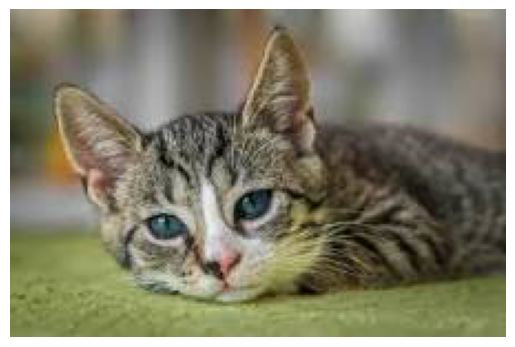

In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

img_path = 'datasets/cat.jpg'

# 1. Load the original, full-resolution image just for displaying
img_for_display = image.load_img(img_path)

# 2. Load and shrink the image to 32x32 specifically for the model
img_for_model = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img_for_model)
img_array = img_array / 255.0
img_input = np.expand_dims(img_array, axis=0)

# 3. Predict
predictions = model.predict(img_input)
predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]

# 4. Display the clear image and the prediction
print(f"Prediction: {predicted_class}")
plt.imshow(img_for_display)
plt.axis('off') # This hides the axis numbers for a cleaner look
plt.show()